<a href="https://colab.research.google.com/github/JagdishMane/numpy-pytorch-tensorflow/blob/main/Flavia_CNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Leaf Classification with CNNs — Flavia Dataset

**Objective:** Build, train, and evaluate a Convolutional Neural Network using Tensorflow and Keras that classifies leaf images from the Flavia Flower Dataset.

**Pipeline:**

0. Import libraries
1. Preprocess the data - Resize, Grayscale, split
2. Build a CNN architecture
3. Train with regularization
4. Evaluate (accuracy, precision, recall, F1)
5. Analyze results (confusion matrix, learned filters, error analysis)



## 0. Import libraries

In [1]:
import os, glob, re, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: []


## 1. Load the Dataset

The  Flavia dataset 'M4-archive.zip' file is uploaded colab notebook path /content/M4-archvie.zip.
The images are extracted and stored in /content/flavia_dataset






In [4]:
# >>> EDIT THIS <<<
import zipfile

ZIP_FILE_PATH = "/content/M4-archive.zip"
EXTRACT_DIR = "/content/flavia_dataset"

# Unzip the dataset
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)


In [9]:
DATA_DIR = os.path.join(EXTRACT_DIR, "Leaves") # folder you unzipped the download into
IMG_SIZE = (128, 128)     # fixed size every image gets resized to
OUTPUT_DIR = "flavia_run"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Known Flavia leaf-ID -> species ranges (Wu et al. 2007 release).
# VERIFY against your copy's README before relying on this for grading-critical labels.
ID_RANGE_TO_SPECIES = {
    (1001, 1059): "pubescent_bamboo",
    (1060, 1122): "chinese_horse_chestnut",
    (1552, 1616): "anhui_barberry",
    (1123, 1194): "chinese_redbud",
    (1195, 1267): "true_indigo",
    (1268, 1323): "japanese_maple",
    (1324, 1385): "nanmu",
    (1386, 1437): "castor_aralia",
    (1497, 1551): "chinese_cinnamon",
    (1438, 1496): "goldenrain_tree",
    (2001, 2050): "big_fruited_holly",
    (2051, 2113): "japanese_cheesewood",
    (2114, 2165): "wintersweet",
    (2166, 2230): "camphortree",
    (2231, 2290): "japan_arrowwood",
    (2291, 2346): "sweet_osmanthus",
    (2347, 2423): "deodar",
    (2424, 2485): "ginkgo_maidenhair_tree",
    (2486, 2546): "crape_myrtle",
    (2547, 2612): "oleander",
    (2616, 2675): "yew_plum_pine",
    (3001, 3055): "japanese_flowering_cherry",
    (3056, 3110): "glossy_privet",
    (3111, 3175): "chinese_toon",
    (3176, 3229): "peach",
    (3230, 3281): "ford_woodlotus",
    (3282, 3334): "trident_maple",
    (3335, 3389): "beales_barberry",
    (3390, 3446): "southern_magnolia",
    (3447, 3510): "canadian_poplar",
    (3511, 3563): "chinese_tulip_tree",
    (3566, 3621): "tangerine"
}

## 2. Preprocess the data

 - Resize the image.
 - Convert to grayscale.
 - Split into train / validation / test.


In [10]:
def id_to_species(filename):
    m = re.search(r"(\d+)", os.path.basename(filename))        ###  Look for the file if not return None
    if not m:
        return None
    leaf_id = int(m.group(1))                                  ### Get the leaf id 1001, 1002 ...
    for (lo, hi), species in ID_RANGE_TO_SPECIES.items():      ### Return leaf species for the matched ID.
        if lo <= leaf_id <= hi:
            return species
    return None


### Returns a list of (filepath, label)
def discover_dataset(data_dir):
    subdirs = [d for d in glob.glob(os.path.join(data_dir, "*")) if os.path.isdir(d)]
    records = []

    ### if subdirectores exists.
    if len(subdirs) >= 2:
        for d in subdirs:
            label = os.path.basename(d.rstrip("/"))
            for fp in glob.glob(os.path.join(d, "*")):
                if fp.lower().endswith(".jpg"):
                    records.append((fp, label))
    else:
        for fp in glob.glob(os.path.join(data_dir, "*")):
            if fp.lower().endswith(".jpg"):
                label = id_to_species(fp)
                if label is not None:
                    records.append((fp, label))

    return records


records = discover_dataset(DATA_DIR)     ### Record - fp and labels
print(f"Found {len(records)} labeled images across "
      f"{len(set(r[1] for r in records))} species.")
assert len(records) > 0, "No images found -- check DATA_DIR and the folder layout."


Found 1907 labeled images across 32 species.


In [11]:
def load_and_preprocess(filepath, size=IMG_SIZE):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)   ### grayscale on read
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

X = np.zeros((len(records), IMG_SIZE[0], IMG_SIZE[1], 1), dtype=np.float32)   ### Initialize X IMG_SIZE=128,128
labels_raw = []

for i, (fp, label) in enumerate(records):
    X[i, :, :, 0] = load_and_preprocess(fp)
    labels_raw.append(label)

X /= 255.0  # normalize to [0, 1]

le = LabelEncoder()
y_int = le.fit_transform(labels_raw)   #### Conver to numerical classess for each leave species.
NUM_CLASSES = len(le.classes_)
y = to_categorical(y_int, NUM_CLASSES)  ### to one-hot encoding [1,0,0,0,........]

print("X shape:", X.shape, "| y shape:", y.shape, "| classes:", NUM_CLASSES)


X shape: (1907, 128, 128, 1) | y shape: (1907, 32) | classes: 32


In [ ]:
TEST_SIZE = 0.15
VAL_SIZE = 0.15           # taken out of the remaining train portion
BATCH_SIZE = 32
EPOCHS = 60

# Stratified train / val / test split
### stratfy ensures each sample of class is equally distributed across train and test dataset.
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y_int, random_state=SEED)

y_train_full_int = np.argmax(y_train_full, axis=1)     ### Convers one-hot encoded back to integer labels
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=VAL_SIZE, stratify=y_train_full_int, random_state=SEED)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1377, 128, 128, 1) Val: (243, 128, 128, 1) Test: (287, 128, 128, 1)


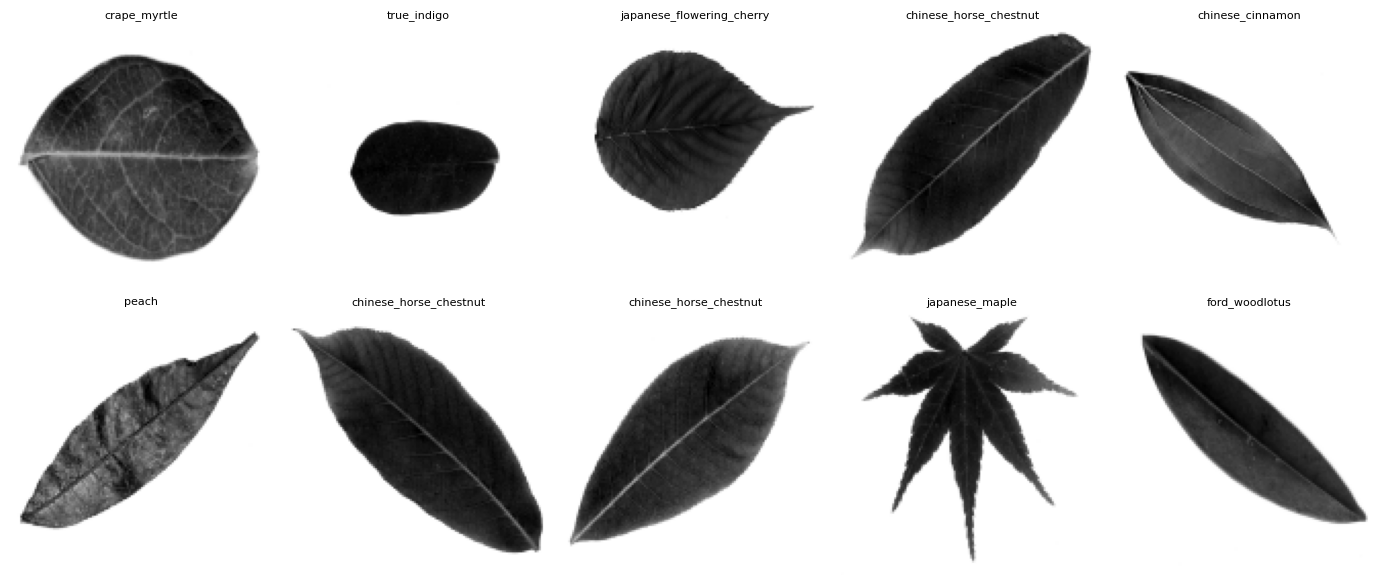

In [13]:
# Sanity check: visualize a handful of samples with their decoded labels
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
idxs = np.random.choice(len(X_train), 10, replace=False)
for ax, idx in zip(axes.ravel(), idxs):
    ax.imshow(X_train[idx, :, :, 0], cmap="gray")
    label = le.inverse_transform([np.argmax(y_train[idx])])[0]
    ax.set_title(label, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [14]:
# Data augmentation applied only at train time (leaves are rotation/flip invariant in this task)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name="augmentation")


## 3. Build the CNN

A four-block convolutional stack (Conv → BatchNorm → ReLU → MaxPool) with dropout for regularization, followed by global average pooling and a dense classification head. Global average pooling (instead of Flatten) keeps the parameter count low and reduces overfitting risk on a dataset this size (~1900 images).


In [15]:
def build_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same",
                           kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="flavia_cnn")


model = build_model(IMG_SIZE + (1,), NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


Model: "flavia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             

 Total params: 463,776 (1.77 MB)

 Trainable params: 462,816 (1.77 MB)

 Non-trainable params: 960 (3.75 KB)

## 4. Train the model

Regularization already present: L2 weight decay, dropout, batch norm, and data augmentation. On top of that we add early stopping (restores best validation weights) and a learning-rate scheduler so training doesn't need a hand-tuned epoch count.


In [16]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, "best_model.keras"),
                     monitor="val_accuracy", save_best_only=True),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.1104 - loss: 3.2429 - val_accuracy: 0.0412 - val_loss: 4.2185 - learning_rate: 0.0010
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.1924 - loss: 2.7841 - val_accuracy: 0.0535 - val_loss: 5.3003 - learning_rate: 0.0010
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.2150 - loss: 2.6362 - val_accuracy: 0.0535 - val_loss: 7.0998 - learning_rate: 0.0010
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.2411 - loss: 2.5088 - val_accuracy: 0.0494 - val_loss: 8.0579 - learning_rate: 0.0010
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.2818 - loss: 2.3836 - val_accuracy: 0.1070 - val_loss: 7.0680 - learning_rate: 0.0010
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.2869 - loss: 2.3084 - val_accuracy: 0.0329 - val_loss: 8.5813 - learning_rate: 0.0010
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.3224 - loss: 2.1838 - val_accura

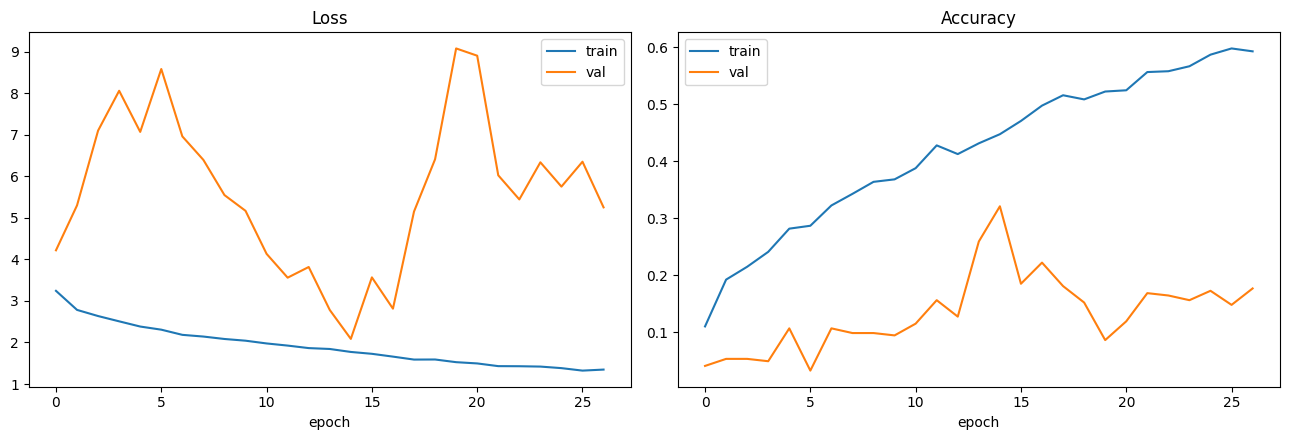

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()


## 5. Evaluate on the test set

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0)
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall:    {recall:.4f}")
print(f"Weighted F1:         {f1:.4f}")

print("\nPer-class report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))


Test loss: 2.1726 | Test accuracy: 0.3345
Weighted precision: 0.3656
Weighted recall:    0.3345
Weighted F1:         0.2939

Per-class report:

                           precision    recall  f1-score   support

           anhui_barberry       0.56      0.50      0.53        10
          beales_barberry       0.75      0.75      0.75         8
        big_fruited_holly       0.00      0.00      0.00         8
              camphortree       1.00      0.10      0.18        10
          canadian_poplar       0.43      0.30      0.35        10
            castor_aralia       0.00      0.00      0.00         8
         chinese_cinnamon       0.12      0.12      0.12         8
   chinese_horse_chestnut       0.30      0.30      0.30        10
           chinese_redbud       0.25      0.64      0.36        11
             chinese_toon       0.27      0.30      0.29        10
       chinese_tulip_tree       0.15      0.25      0.19         8
             crape_myrtle       0.80      0.89     

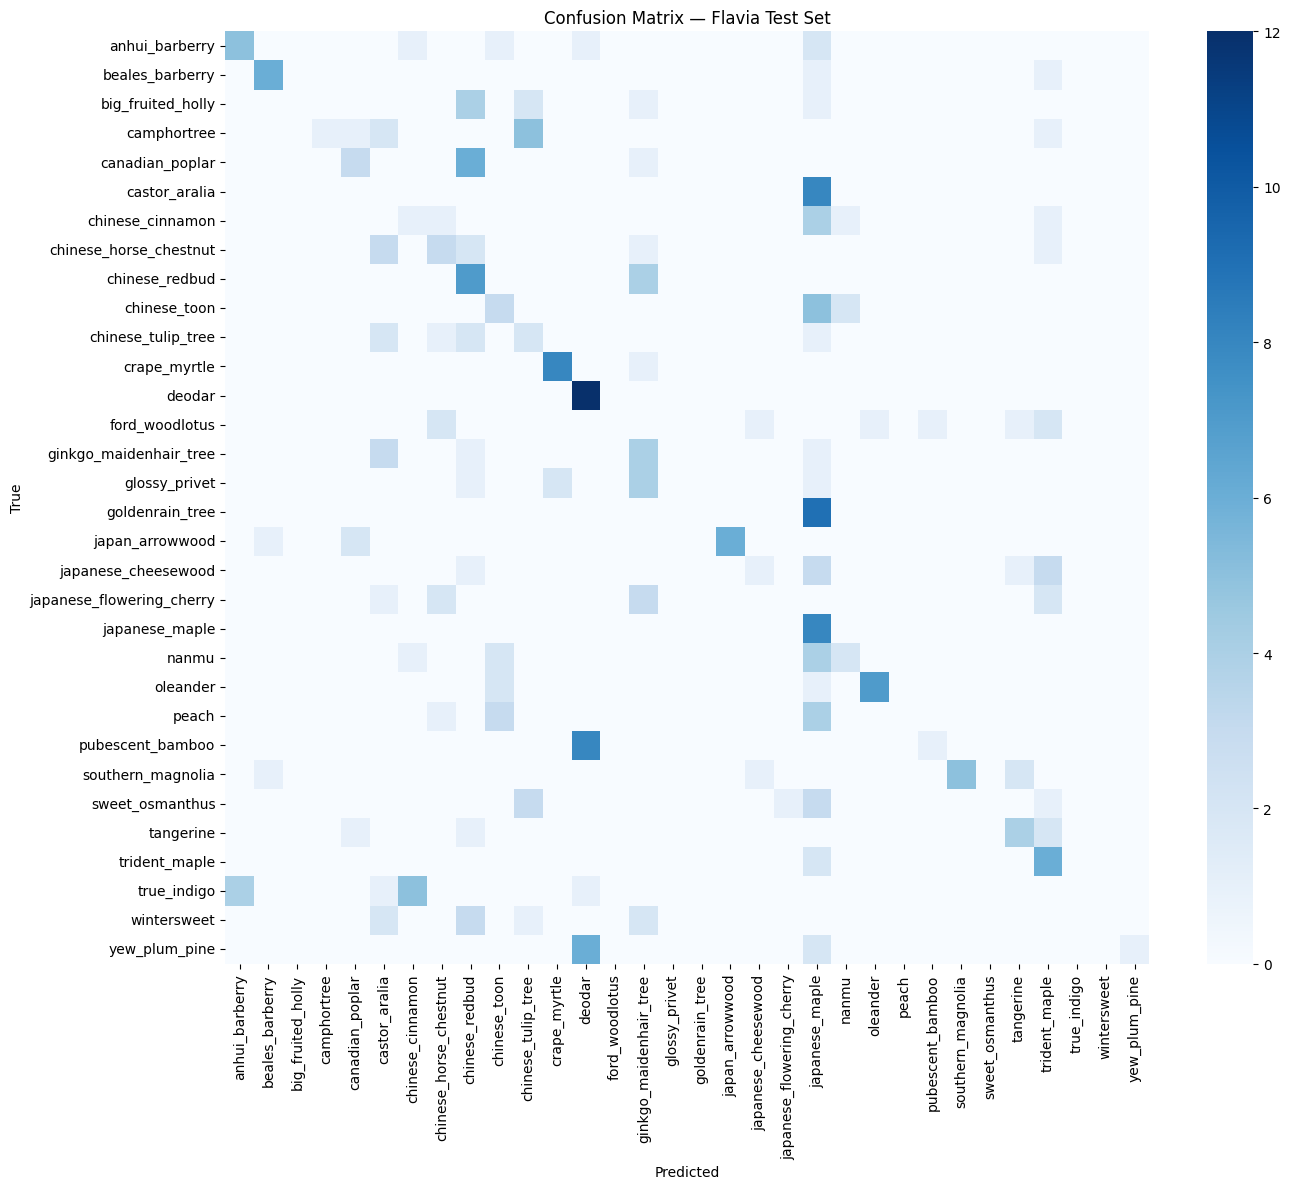

In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Flavia Test Set")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()


## 6. Analyze the results

### 6.1 Misclassified examples
Looking at the actual errors is usually more informative than the aggregate metrics above — it tells you whether mistakes are concentrated in visually similar species or spread randomly.


191 / 287 test images misclassified (66.6%)


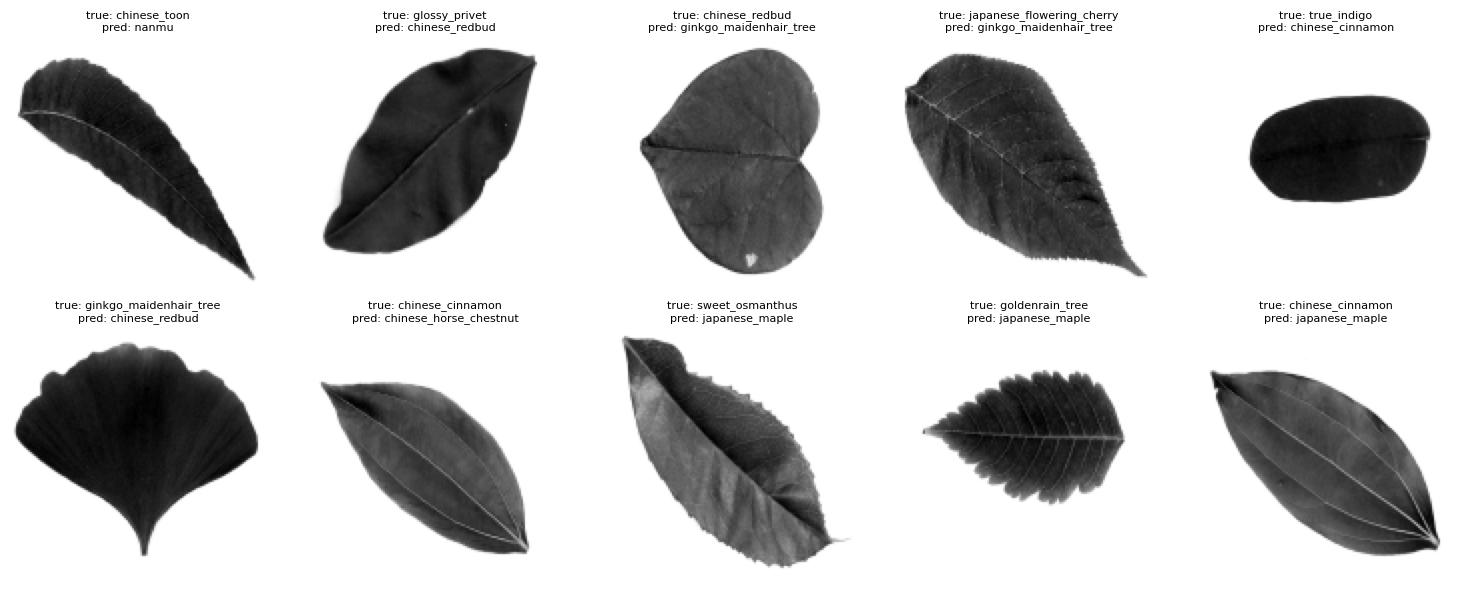

In [20]:
wrong_idx = np.where(y_pred != y_true)[0]
print(f"{len(wrong_idx)} / {len(y_true)} test images misclassified "
      f"({len(wrong_idx)/len(y_true):.1%})")

n_show = min(10, len(wrong_idx))
show_idx = np.random.choice(wrong_idx, n_show, replace=False) if n_show else []

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.ravel(), show_idx):
    ax.imshow(X_test[idx, :, :, 0], cmap="gray")
    true_lbl = le.classes_[y_true[idx]]
    pred_lbl = le.classes_[y_pred[idx]]
    ax.set_title(f"true: {true_lbl}\npred: {pred_lbl}", fontsize=8)
    ax.axis("off")
for ax in axes.ravel()[len(show_idx):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


### 6.2 Learned feature maps
Visualizing what an intermediate convolutional layer activates on for a sample leaf shows what kind of features the network has learned to key on (edges/veins early on, more abstract shape descriptors deeper in).


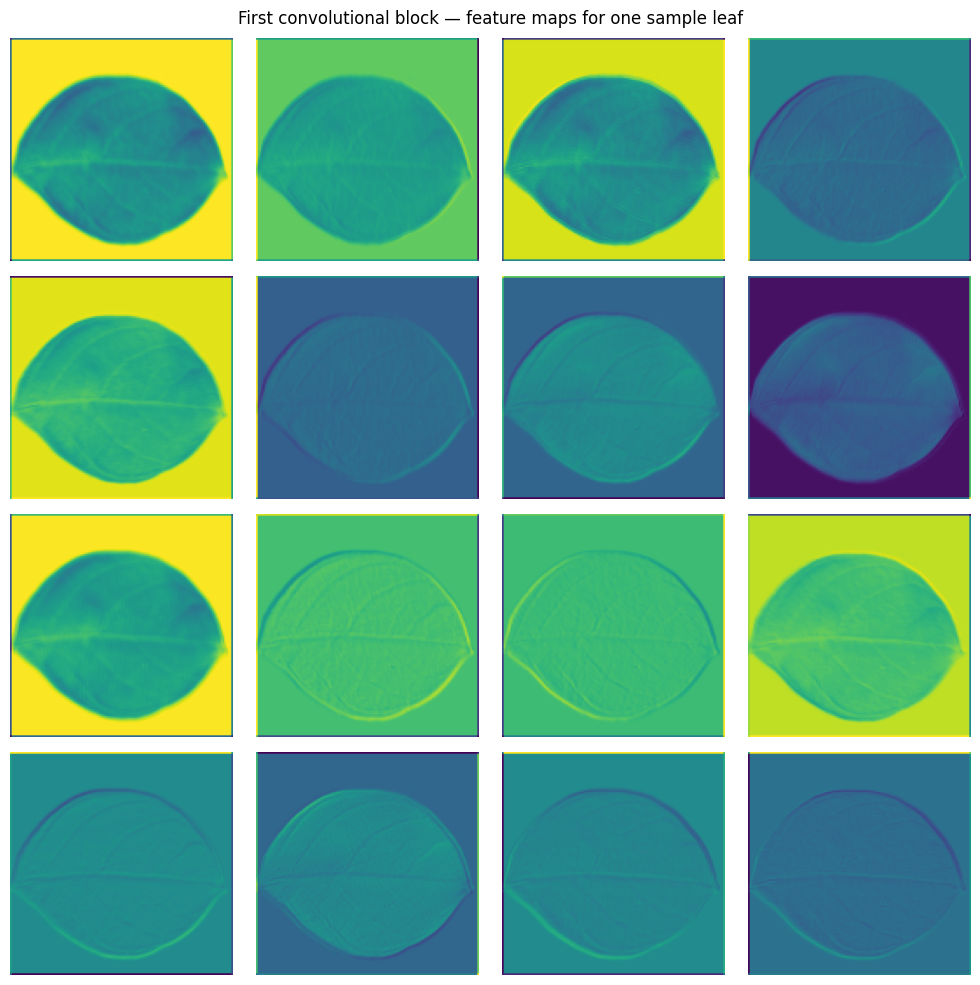

In [21]:
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, layers.Conv2D)]
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)

sample = X_test[0:1]
activations = activation_model.predict(sample, verbose=0)

first_layer_activation = activations[0]
n_filters = min(16, first_layer_activation.shape[-1])

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    if i < n_filters:
        ax.imshow(first_layer_activation[0, :, :, i], cmap="viridis")
    ax.axis("off")
plt.suptitle("First convolutional block — feature maps for one sample leaf")
plt.tight_layout()
plt.show()


**Overall Performance**: The model achieved a Test Accuracy of 33.45%. This is significantly better than a naive random guessing baseline (which would be approximately 1/32 ≈ 3.1%), indicating the model has learned some patterns.

- Weighted Precision: 0.3656
- Weighted Recall: 0.3345
- Weighted F1: 0.2939

**Error Patterns**: From the classification report and the misclassified examples, it's evident that the model struggles significantly with many classes. For instance, species like 'big_fruited_holly', 'castor_aralia', 'glossy_privet', 'japanese_flowering_cherry', 'peach', 'sweet_osmanthus', 'true_indigo', and 'wintersweet' have 0.00 for precision, recall, and F1-score, meaning the model completely failed to correctly identify any samples from these classes in the test set. Other classes show varying performance, with some being classified much better (e.g., 'beales_barberry', 'crape_myrtle', 'deodar', 'japan_arrowwood', 'oleander', 'southern_magnolia'). A total of 191 out of 287 test images were misclassified (66.6%).

**Overfitting Check**: By looking at the training curves (loss and accuracy), there's a visible gap between the training and validation metrics. The training accuracy continued to increase, while the validation accuracy peaked early (around epoch 17 with ~22% accuracy) and then generally decreased or fluctuated, and the validation loss increased after a few epochs. This suggests that despite the regularization techniques applied (L2 weight decay, dropout, batch norm, and data augmentation), the model still exhibits signs of overfitting to the training data. Early stopping did help to restore the best weights, but the divergence indicates the model might be too complex for the dataset size or the augmentation isn't sufficient.

**Dataset Size Impact**: The notebook correctly points out that with approximately 60 images per class, the per-class support can heavily influence the per-class F1 score. The severe imbalance in performance across classes confirms this, as some classes with fewer or less distinct features might be harder for the model to learn effectively given the limited samples.